In [1]:
import re
import gc

from collections import Counter, defaultdict
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import torch

import warnings
warnings.filterwarnings(action="ignore")

from pymorphy3 import MorphAnalyzer
from stop_words import get_stop_words

from IPython.display import display

import matplotlib as mpl
mpl.rcParams["font.style"] = "oblique"
mpl.rcParams["axes.grid"] = True

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.preprocessing import normalize, Normalizer
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import NearestNeighbors

from umap import UMAP
from hdbscan import HDBSCAN

from sklearn.metrics import (
    adjusted_rand_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.metrics.cluster import pair_confusion_matrix
from scipy.stats import spearmanr

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

In [2]:
df = pd.read_csv("./Разметка_текущая (1).csv")
df.head()

,row_id,text,original_label,story_id,message_type,hierarchy_l1,hierarchy_l2,hierarchy_l3,hierarchy_l4,hierarchy_l5,hierarchy,hF1_path,hF1_ancestors,story_size,review_status,review_reason
0,1,"❗️Визит президента Сербии в силе, он летит в М...",9may_politics,vucic_victory_day_moscow_visit,fact,politics,international_relations,russia_serbia,victory_day_80,NaN,politics/international_relations/russia_serbia...,root/politics/international_relations/russia_s...,root|root/politics|root/politics/international...,15,review,check_boundary_with_adjacent_story
1,2,"Самолет президента Сербии Вучича, направлявший...",9may_politics,vucic_victory_day_moscow_visit,fact,politics,international_relations,russia_serbia,victory_day_80,NaN,politics/international_relations/russia_serbia...,root/politics/international_relations/russia_s...,root|root/politics|root/politics/international...,15,review,check_boundary_with_adjacent_story
2,3,Власти Литвы запретили перелет в воздушном про...,9may_politics,vucic_victory_day_moscow_visit,fact,politics,international_relations,russia_serbia,victory_day_80,NaN,politics/international_relations/russia_serbia...,root/politics/international_relations/russia_s...,root|root/politics|root/politics/international...,15,review,check_boundary_with_adjacent_story
3,4,"Вучич, прервавший поездку в США из-за недомога...",9may_politics,vucic_victory_day_moscow_visit,fact,politics,international_relations,russia_serbia,victory_day_80,NaN,politics/international_relations/russia_serbia...,root/politics/international_relations/russia_s...,root|root/politics|root/politics/international...,15,review,check_boundary_with_adjacent_story;exact_dupli...
4,5,"Вучич, прервавший поездку в США из-за недомога...",vuchich_ill,vucic_health_incident,fact,politics,europe,serbia,leadership_health,NaN,politics/europe/serbia/leadership_health,root/politics/europe/serbia/leadership_health/...,root|root/politics|root/politics/europe|root/p...,4,review,check_boundary_with_adjacent_story;exact_dupli...


In [3]:
df.shape

(863, 16)

In [4]:
MORPH = MorphAnalyzer()
RU_STOPWORDS = set(get_stop_words("russian"))

In [5]:
#del model_embeddings2

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

In [6]:
model_statistics = make_pipeline(
    TfidfVectorizer(
        lowercase=True,
        max_features=50000,
        ngram_range=(1, 2)
    ),
    TruncatedSVD(
        n_components=300,
        random_state=42
    ),
    Normalizer(copy=False)
)

In [7]:
# todo: run both
model_embeddings1 = SentenceTransformer(
    "jinaai/jina-embeddings-v3", trust_remote_code=True, device="cuda"
)
#model_embeddings2 = SentenceTransformer(
#    "jinaai/jina-embeddings-v5-text-small", trust_remote_code=True, device="cuda"
#)

# gpu issue (FP 16 mode)
#model_embeddings1.half()
#model_embeddings2.half()

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention impl

In [8]:
def make_noise_singletons(y_pred, noise_label=-1):
    y_pred = np.asarray(y_pred).copy()
    noise_mask = y_pred == noise_label

    if not np.any(noise_mask):
        return y_pred

    non_noise = y_pred[~noise_mask]
    next_label = int(np.max(non_noise)) + 1 if non_noise.size else 0

    for offset, idx in enumerate(np.where(noise_mask)[0]):
        y_pred[idx] = next_label + offset

    return y_pred


def pairwise_metrics(y_true, y_pred):
    tn, fp, fn, tp = pair_confusion_matrix(y_true, y_pred).ravel()

    precision = tp / (tp + fp) if tp + fp > 0 else 0
    recall = tp / (tp + fn) if tp + fn > 0 else 0

    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0

    return precision, recall, f1

In [9]:
def compute_true_paths(df, col="hF1_ancestors", sep="|"):
    return [
        [node for node in str(value).split(sep) if node]
        for value in df[col]
    ]


def strip_root(path, root="root"):
    return [node for node in path if node != root]


def gold_hierarchy_nodes(true_paths, root="root", min_size=2):
    n = len(true_paths)
    groups = defaultdict(list)

    for i, path in enumerate(true_paths):
        for node in strip_root(path, root):
            groups[node].append(i)

    return [
        frozenset(indices)
        for indices in groups.values()
        if min_size <= len(set(indices)) < n
    ]


def linkage_to_hierarchy_nodes(Z, n_samples, min_size=2, include_root=False):
    if Z is None:
        return []

    clusters = {i: frozenset([i]) for i in range(n_samples)}
    nodes = []

    for step, (left, right, _, _) in enumerate(np.asarray(Z)):
        left, right = int(left), int(right)
        leaves = clusters[left] | clusters[right]

        if len(leaves) >= min_size and (include_root or len(leaves) < n_samples):
            nodes.append(leaves)

        clusters[n_samples + step] = leaves

    return nodes


def weighted_best_overlap_f1(source_nodes, target_nodes):
    if not source_nodes or not target_nodes:
        return np.nan

    total_weight = 0
    weighted_sum = 0.0

    for source in source_nodes:
        source_size = len(source)
        best_f1 = 0.0

        for target in target_nodes:
            intersection = len(source & target)
            if intersection == 0:
                continue

            best_f1 = max(
                best_f1,
                2 * intersection / (len(source) + len(target))
            )

        weighted_sum += source_size * best_f1
        total_weight += source_size

    return weighted_sum / total_weight if total_weight else np.nan


def hierarchical_cluster_fscore(tree_linkage, true_paths, root="root", min_size=2):
    n = len(true_paths)
    gold_nodes = gold_hierarchy_nodes(true_paths, root=root, min_size=min_size)
    pred_nodes = linkage_to_hierarchy_nodes(tree_linkage, n, min_size=min_size)

    h_precision = weighted_best_overlap_f1(pred_nodes, gold_nodes)
    h_recall = weighted_best_overlap_f1(gold_nodes, pred_nodes)

    if np.isfinite(h_precision) and np.isfinite(h_recall) and h_precision + h_recall > 0:
        h_f1 = 2 * h_precision * h_recall / (h_precision + h_recall)
    else:
        h_f1 = np.nan

    return h_precision, h_recall, h_f1


def dendrogram_purity(tree_linkage, y_true):
    if tree_linkage is None:
        return np.nan

    y_true = np.asarray(y_true)
    n = len(y_true)

    sizes = {i: 1 for i in range(n)}
    counts = {i: Counter([y_true[i]]) for i in range(n)}

    purity_sum = 0.0
    pair_count = 0

    for step, (left, right, _, _) in enumerate(np.asarray(tree_linkage)):
        left, right = int(left), int(right)

        left_counts = counts[left]
        right_counts = counts[right]
        merged_counts = left_counts + right_counts
        merged_size = sizes[left] + sizes[right]

        for label in left_counts.keys() & right_counts.keys():
            cross_pairs = left_counts[label] * right_counts[label]
            pair_purity = merged_counts[label] / merged_size

            purity_sum += cross_pairs * pair_purity
            pair_count += cross_pairs

        new_cluster_id = n + step
        sizes[new_cluster_id] = merged_size
        counts[new_cluster_id] = merged_counts

    return purity_sum / pair_count if pair_count else np.nan


def common_prefix_len(path_a, path_b, root="root"):
    length = 0

    for node_a, node_b in zip(path_a, path_b):
        if node_a != node_b:
            break
        if node_a != root:
            length += 1

    return length


@lru_cache(maxsize=8)
def _gold_hierarchy_pairwise_arrays_cached(paths, root="root"):
    n = len(paths)
    n_pairs = n * (n - 1) // 2

    lca_similarity = np.empty(n_pairs, dtype=float)
    tree_distance = np.empty(n_pairs, dtype=float)
    path_depths = [len(strip_root(path, root=root)) for path in paths]

    k = 0
    for i in range(n - 1):
        for j in range(i + 1, n):
            lca_depth = common_prefix_len(paths[i], paths[j], root=root)

            lca_similarity[k] = lca_depth
            tree_distance[k] = path_depths[i] + path_depths[j] - 2 * lca_depth
            k += 1

    return lca_similarity, tree_distance


def gold_hierarchy_pairwise_arrays(true_paths, root="root"):
    return _gold_hierarchy_pairwise_arrays_cached(
        tuple(tuple(path) for path in true_paths),
        root=root,
    )


def condensed_index(n, i, j):
    if i > j:
        i, j = j, i

    return n * i - i * (i + 1) // 2 + j - i - 1


def linkage_cophenetic_distances(Z, n_samples):
    distances = np.empty(n_samples * (n_samples - 1) // 2, dtype=float)
    clusters = {i: [i] for i in range(n_samples)}

    for step, (left, right, distance, _) in enumerate(np.asarray(Z)):
        left, right = int(left), int(right)

        for i in clusters[left]:
            for j in clusters[right]:
                distances[condensed_index(n_samples, i, j)] = distance

        clusters[n_samples + step] = clusters[left] + clusters[right]

    return distances


def safe_spearman(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 2:
        return np.nan

    x = x[mask]
    y = y[mask]

    if len(np.unique(x)) < 2 or len(np.unique(y)) < 2:
        return np.nan

    return spearmanr(x, y).correlation


def hierarchical_tree_metrics(tree_linkage, true_paths, root="root"):
    if tree_linkage is None:
        return {
            "lca_similarity_spearman": np.nan,
            "tree_distance_spearman": np.nan,
        }

    n = len(true_paths)
    gold_lca, gold_distance = gold_hierarchy_pairwise_arrays(true_paths, root=root)
    pred_distance = linkage_cophenetic_distances(tree_linkage, n)

    return {
        "lca_similarity_spearman": safe_spearman(gold_lca, -pred_distance),
        "tree_distance_spearman": safe_spearman(gold_distance, pred_distance),
    }


In [10]:
def tfidf_preprocessing(text):
    text = re.sub(r"[^а-яё\s]", " ", text.lower())
    result = []

    for token in text.split():
        if len(token) < 2: continue
        lemma = MORPH.parse(token)[0].normal_form
        if lemma in RU_STOPWORDS: continue

        result.append(lemma)

    return " ".join(result)

In [11]:
def clustering_metrics(X, y_true, y_pred, true_paths=None, tree_linkage=None):
    y_pred_external = make_noise_singletons(y_pred)
    precision, recall, f1 = pairwise_metrics(y_true, y_pred_external)
    ari = adjusted_rand_score(y_true, y_pred_external)

    if true_paths is not None:
        h_precision, h_recall, h_f1 = hierarchical_cluster_fscore(
            tree_linkage=tree_linkage,
            true_paths=true_paths,
        )
        tree_metrics = hierarchical_tree_metrics(tree_linkage, true_paths)
        purity = dendrogram_purity(tree_linkage, y_true)
    else:
        h_precision, h_recall, h_f1 = np.nan, np.nan, np.nan
        tree_metrics = {
            "lca_similarity_spearman": np.nan,
            "tree_distance_spearman": np.nan,
        }
        purity = np.nan

    mask = y_pred != -1
    internal = {
        "silhouette": np.nan,
        "calinski_harabasz": np.nan,
        "davies_bouldin": np.nan,
    }

    if len(set(y_pred[mask])) >= 2:
        internal["silhouette"] = silhouette_score(X[mask], y_pred[mask])
        internal["calinski_harabasz"] = calinski_harabasz_score(X[mask], y_pred[mask])
        internal["davies_bouldin"] = davies_bouldin_score(X[mask], y_pred[mask])

    return {
        "precision": precision,
        "recall": recall,
        "f1-score": f1,
        "h_precision": h_precision,
        "h_recall": h_recall,
        "h_f1-score": h_f1,
        "lca_similarity_spearman": tree_metrics["lca_similarity_spearman"],
        "tree_distance_spearman": tree_metrics["tree_distance_spearman"],
        "dendrogram_purity": purity,
        "ari": ari,
        **internal
    }


In [12]:
def twonn_dimension(X, metric="euclidean", eps=1e-12):
    X = np.asarray(X)

    if len(X) < 3:
        return np.nan

    nn = NearestNeighbors(n_neighbors=3, metric=metric)
    nn.fit(X)
    distances, _ = nn.kneighbors(X)

    r1 = distances[:, 1]
    r2 = distances[:, 2]
    mask = np.isfinite(r1) & np.isfinite(r2) & (r1 > eps) & (r2 > eps)

    if mask.sum() < 3:
        return np.nan

    log_mu = np.log(r2[mask] / r1[mask])
    mean_log_mu = np.mean(log_mu)

    return 1 / mean_log_mu if mean_log_mu > eps else np.nan


def reduce_embeddings(X, pca_dim=100, umap_dim=15, return_twonn=False, use_pca=False):
    twonn_raw = twonn_dimension(X)

    X_norm = normalize(X)
    pca_dim = min(pca_dim, X_norm.shape[1], X_norm.shape[0] - 1)
    if use_pca:
        X_pca = PCA(
            n_components=pca_dim,
            random_state=42
        ).fit_transform(X_norm)
    else:
        X_pca = X_norm.copy()
        
    twonn_pca = twonn_dimension(X_pca)
    X_umap = UMAP(
        n_components=umap_dim,
        metric="cosine",
        random_state=42
    ).fit_transform(X_pca)
    twonn_umap = twonn_dimension(X_umap)

    if return_twonn:
        return X_umap, {
            "twonn_raw": twonn_raw,
            "twonn_pca": twonn_pca,
            "twonn_umap": twonn_umap,
        }

    return X_umap


In [13]:
def run_clusterers(X, min_cluster_size=5):
    hdbscan = HDBSCAN(
        min_cluster_size=min_cluster_size,
        metric="euclidean"
    ).fit(X)

    return {
        "hdbscan": {
            "labels": hdbscan.labels_,
            "tree_linkage": hdbscan.single_linkage_tree_.to_numpy(),
        },
    }


In [14]:
#for tf-idf
df["text_processed"] = df["text"].apply(tfidf_preprocessing)

In [15]:
texts = df["text"].astype(str).tolist()
preproc_texts = df["text_processed"].tolist()
y_true = df["original_label"].astype(str).to_numpy()
true_paths = compute_true_paths(df)

embeddings_dict = {}
embeddings_dict["tfidf_svd"] = model_statistics.fit_transform(preproc_texts)
#embeddings_dict["jina_embeddings_v3"] = model_embeddings1.encode(
#    texts,
#    task="separation",
#    batch_size=8,
#    show_progress_bar=True,
#    normalize_embeddings=True
#)
#embeddings_dict["jina_embeddings_v5-text-small"] = model_embeddings2.encode(
#    texts,
#    task="text-matching",
#    batch_size=8,
#    show_progress_bar=True,
#    normalize_embeddings=True
#)


In [16]:
embeddings_dict["jina_embeddings_v5_text_small_matching"] = np.load("./embeddings/embeddings_v5_text_small.npy")
embeddings_dict["jina_embeddings_v3"] = np.load("./embeddings/embeddings_v3_separation.npy")

In [17]:
def make_space_id(emb_name, reduction_method, reduction_dim=None):
    if reduction_dim is None:
        return f"{emb_name}__{reduction_method}"

    return f"{emb_name}__{reduction_method}_{reduction_dim}"


def build_embedding_spaces(
    embeddings_dict,
    umap_dims=(5, 10, 15, 30, 50),
    include_raw=True,
    pca_dim=100,
):
    spaces = {}

    for emb_name, X_raw in embeddings_dict.items():
        print(f"Preparing spaces for embeddings: {emb_name}")
        use_pca = False if "jina_embeddings" in emb_name else True

        if include_raw:
            X_raw_norm = normalize(X_raw)
            space_id = make_space_id(emb_name, "raw", X_raw_norm.shape[1])
            spaces[space_id] = {
                "space_id": space_id,
                "embeddings": emb_name,
                "reduction": "raw",
                "reduction_dim": X_raw_norm.shape[1],
                "X": X_raw_norm,
                "twonn": {
                    "twonn_raw": twonn_dimension(X_raw),
                    "twonn_pca": np.nan,
                    "twonn_umap": np.nan,
                    "twonn_space": twonn_dimension(X_raw_norm),
                },
            }

        for umap_dim in umap_dims:
            print(f"  UMAP dim: {umap_dim}")
            X_reduced, twonn_metrics = reduce_embeddings(
                X_raw,
                pca_dim=pca_dim,
                umap_dim=umap_dim,
                return_twonn=True,
                use_pca=use_pca,
            )
            twonn_metrics = dict(twonn_metrics)
            twonn_metrics["twonn_space"] = twonn_metrics["twonn_umap"]

            space_id = make_space_id(emb_name, "umap", umap_dim)
            spaces[space_id] = {
                "space_id": space_id,
                "embeddings": emb_name,
                "reduction": "umap",
                "reduction_dim": umap_dim,
                "X": X_reduced,
                "twonn": twonn_metrics,
            }

    return spaces


def full_pipeline(
    embeddings_dict,
    min_cluster_sizes=[5, 10, 15, 20],
    umap_dims=(5, 10, 15, 30, 50),
    include_raw=True,
):
    spaces = build_embedding_spaces(
        embeddings_dict,
        umap_dims=umap_dims,
        include_raw=include_raw,
    )

    results_total = {}
    for idx, min_cluster_size in enumerate(min_cluster_sizes):
        results_clustering = []
        print(f"{idx+1} out of {len(min_cluster_sizes)}")

        for space_id, space_data in spaces.items():
            X_space = space_data["X"]
            twonn_metrics = space_data["twonn"]
        
            clusterers_output = run_clusterers(
                X_space,
                min_cluster_size=min_cluster_size,
            )
        
            for algo_name, clusterer_output in clusterers_output.items():
                y_pred = clusterer_output["labels"]
                tree_linkage = clusterer_output["tree_linkage"]
                metrics = clustering_metrics(
                    X=X_space,
                    y_true=y_true,
                    y_pred=y_pred,
                    true_paths=true_paths,
                    tree_linkage=tree_linkage,
                )
        
                results_clustering.append({
                    "space_id": space_id,
                    "embeddings": space_data["embeddings"],
                    "reduction": space_data["reduction"],
                    "reduction_dim": space_data["reduction_dim"],
                    "algorithm": algo_name,
                    **metrics,
                    **twonn_metrics,
                    "n_pred_clusters": len(set(y_pred)) - int(-1 in y_pred),
                    "n_noise": int(np.sum(y_pred == -1)),
                })
        
        results_df = pd.DataFrame(results_clustering)
        results_df = results_df[
            [
                "algorithm",
                "space_id",
                "embeddings",
                "reduction",
                "reduction_dim",
                "precision",
                "recall",
                "f1-score",
                "h_precision",
                "h_recall",
                "h_f1-score",
                "lca_similarity_spearman",
                "tree_distance_spearman",
                "dendrogram_purity",
                "ari",
                "silhouette",
                "calinski_harabasz",
                "davies_bouldin",
                "twonn_raw",
                "twonn_pca",
                "twonn_umap",
                "twonn_space",
                "n_pred_clusters",
                "n_noise",
            ]
        ]
        results_total[f"res_{min_cluster_size}"] = results_df
    
    return results_total


In [18]:
results_dfs = full_pipeline(
    embeddings_dict,
    min_cluster_sizes=np.arange(2, 30, 1),
    umap_dims=[5, 10, 15, 30, 50],
    include_raw=True,
)


Preparing spaces for embeddings: tfidf_svd
  UMAP dim: 5
  UMAP dim: 10
  UMAP dim: 15
  UMAP dim: 30
  UMAP dim: 50
Preparing spaces for embeddings: jina_embeddings_v5_text_small_matching
  UMAP dim: 5
  UMAP dim: 10
  UMAP dim: 15
  UMAP dim: 30
  UMAP dim: 50
Preparing spaces for embeddings: jina_embeddings_v3
  UMAP dim: 5
  UMAP dim: 10
  UMAP dim: 15
  UMAP dim: 30
  UMAP dim: 50
1 out of 28
2 out of 28
3 out of 28
4 out of 28
5 out of 28
6 out of 28
7 out of 28
8 out of 28
9 out of 28
10 out of 28
11 out of 28
12 out of 28
13 out of 28
14 out of 28
15 out of 28
16 out of 28
17 out of 28
18 out of 28
19 out of 28
20 out of 28
21 out of 28
22 out of 28
23 out of 28
24 out of 28
25 out of 28
26 out of 28
27 out of 28
28 out of 28


In [19]:
for title, df in list(results_dfs.items())[:5]:
    print(title)
    display(df)

res_2


,algorithm,space_id,embeddings,reduction,reduction_dim,precision,recall,f1-score,h_precision,h_recall,...,ari,silhouette,calinski_harabasz,davies_bouldin,twonn_raw,twonn_pca,twonn_umap,twonn_space,n_pred_clusters,n_noise
0,hdbscan,tfidf_svd__raw_300,tfidf_svd,raw,300,0.789959,0.215270,0.338340,0.480976,0.571408,...,0.330678,0.154571,4.423986,1.850667,5.884047,NaN,NaN,5.884047,89,305
1,hdbscan,tfidf_svd__umap_5,tfidf_svd,umap,5,0.871109,0.399759,0.548025,0.592012,0.795562,...,0.540295,0.676881,4552.710691,0.440457,5.884047,4.828226,2.819595,2.819595,96,76
2,hdbscan,tfidf_svd__umap_10,tfidf_svd,umap,10,0.873711,0.417564,0.565069,0.597183,0.802291,...,0.557419,0.671658,4073.258780,0.476287,5.884047,4.828226,2.852377,2.852377,93,86
3,hdbscan,tfidf_svd__umap_15,tfidf_svd,umap,15,0.797386,0.441807,0.568580,0.602296,0.795675,...,0.560199,0.705152,2899.034976,0.426640,5.884047,4.828226,2.934265,2.934265,88,85
4,hdbscan,tfidf_svd__umap_30,tfidf_svd,umap,30,0.825837,0.506086,0.627581,0.613767,0.807537,...,0.619860,0.691927,2677.045076,0.479750,5.884047,4.828226,2.872769,2.872769,88,65
5,hdbscan,tfidf_svd__umap_50,tfidf_svd,umap,50,0.804926,0.407605,0.541169,0.582284,0.790350,...,0.532773,0.680677,3135.795111,0.463563,5.884047,4.828226,2.797952,2.797952,94,94
6,hdbscan,jina_embeddings_v5_text_small_matching__raw_1024,jina_embeddings_v5_text_small_matching,raw,1024,0.775212,0.341012,0.473662,0.470622,0.540340,...,0.464924,0.197281,10.399685,1.417667,12.321333,NaN,NaN,8.348272,55,410
7,hdbscan,jina_embeddings_v5_text_small_matching__umap_5,jina_embeddings_v5_text_small_matching,umap,5,0.908975,0.575596,0.704853,0.641731,0.822758,...,0.698607,0.688204,6351.240091,0.469205,12.321333,8.348272,2.887091,2.887091,79,89
8,hdbscan,jina_embeddings_v5_text_small_matching__umap_10,jina_embeddings_v5_text_small_matching,umap,10,0.878234,0.638467,0.739399,0.639582,0.824461,...,0.733400,0.671832,4303.941146,0.510807,12.321333,8.348272,3.168337,3.168337,77,58
9,hdbscan,jina_embeddings_v5_text_small_matching__umap_15,jina_embeddings_v5_text_small_matching,umap,15,0.910953,0.644201,0.754699,0.637403,0.823414,...,0.749145,0.710749,4069.667625,0.464373,12.321333,8.348272,3.072330,3.072330,80,79


res_3


,algorithm,space_id,embeddings,reduction,reduction_dim,precision,recall,f1-score,h_precision,h_recall,...,ari,silhouette,calinski_harabasz,davies_bouldin,twonn_raw,twonn_pca,twonn_umap,twonn_space,n_pred_clusters,n_noise
0,hdbscan,tfidf_svd__raw_300,tfidf_svd,raw,300,0.839687,0.161754,0.271255,0.477357,0.536845,...,0.264908,0.176949,5.122118,1.874409,5.884047,NaN,NaN,5.884047,60,434
1,hdbscan,tfidf_svd__umap_5,tfidf_svd,umap,5,0.830134,0.461121,0.592899,0.604292,0.788804,...,0.584977,0.714863,4763.845168,0.383733,5.884047,4.828226,2.819595,2.819595,73,90
2,hdbscan,tfidf_svd__umap_10,tfidf_svd,umap,10,0.795585,0.489387,0.606004,0.606205,0.797455,...,0.597816,0.700022,3872.147585,0.427230,5.884047,4.828226,2.852377,2.852377,72,79
3,hdbscan,tfidf_svd__umap_15,tfidf_svd,umap,15,0.798738,0.534956,0.640761,0.618964,0.796523,...,0.632890,0.718454,3052.032442,0.388768,5.884047,4.828226,2.934265,2.934265,66,88
4,hdbscan,tfidf_svd__umap_30,tfidf_svd,umap,30,0.817477,0.647420,0.722578,0.624907,0.802288,...,0.715865,0.739805,3204.332285,0.357999,5.884047,4.828226,2.872769,2.872769,59,64
5,hdbscan,tfidf_svd__umap_50,tfidf_svd,umap,50,0.831852,0.555377,0.666063,0.599090,0.786505,...,0.658761,0.701568,3613.491580,0.423841,5.884047,4.828226,2.797952,2.797952,66,67
6,hdbscan,jina_embeddings_v5_text_small_matching__raw_1024,jina_embeddings_v5_text_small_matching,raw,1024,0.753885,0.297656,0.426799,0.459506,0.487242,...,0.417993,0.217631,13.671086,1.444633,12.321333,NaN,NaN,8.348272,31,509
7,hdbscan,jina_embeddings_v5_text_small_matching__umap_5,jina_embeddings_v5_text_small_matching,umap,5,0.908824,0.684841,0.781092,0.653682,0.815150,...,0.775946,0.731723,7114.041178,0.411611,12.321333,8.348272,2.887091,2.887091,57,94
8,hdbscan,jina_embeddings_v5_text_small_matching__umap_10,jina_embeddings_v5_text_small_matching,umap,10,0.876659,0.697817,0.777081,0.644903,0.811100,...,0.771672,0.699127,5013.703742,0.453757,12.321333,8.348272,3.168337,3.168337,60,85
9,hdbscan,jina_embeddings_v5_text_small_matching__umap_15,jina_embeddings_v5_text_small_matching,umap,15,0.854297,0.741978,0.794186,0.645815,0.815340,...,0.788942,0.717672,4136.389883,0.411145,12.321333,8.348272,3.072330,3.072330,57,65


res_4


,algorithm,space_id,embeddings,reduction,reduction_dim,precision,recall,f1-score,h_precision,h_recall,...,ari,silhouette,calinski_harabasz,davies_bouldin,twonn_raw,twonn_pca,twonn_umap,twonn_space,n_pred_clusters,n_noise
0,hdbscan,tfidf_svd__raw_300,tfidf_svd,raw,300,0.735637,0.171311,0.277905,0.463413,0.472313,...,0.270540,0.140467,5.360649,2.243719,5.884047,NaN,NaN,5.884047,33,515
1,hdbscan,tfidf_svd__umap_5,tfidf_svd,umap,5,0.773767,0.646816,0.704619,0.615911,0.784536,...,0.697251,0.724894,3205.061396,0.340916,5.884047,4.828226,2.819595,2.819595,56,66
2,hdbscan,tfidf_svd__umap_10,tfidf_svd,umap,10,0.810380,0.598431,0.688462,0.608471,0.792880,...,0.681224,0.741275,3938.380557,0.351340,5.884047,4.828226,2.852377,2.852377,56,88
3,hdbscan,tfidf_svd__umap_15,tfidf_svd,umap,15,0.784065,0.683030,0.730068,0.607374,0.788450,...,0.723179,0.741967,2809.075957,0.351222,5.884047,4.828226,2.934265,2.934265,52,73
4,hdbscan,tfidf_svd__umap_30,tfidf_svd,umap,30,0.790649,0.644704,0.710257,0.615048,0.783217,...,0.703129,0.736023,3128.428415,0.380648,5.884047,4.828226,2.872769,2.872769,52,76
5,hdbscan,tfidf_svd__umap_50,tfidf_svd,umap,50,0.822374,0.631526,0.714424,0.606764,0.779934,...,0.707636,0.718489,3536.080974,0.385925,5.884047,4.828226,2.797952,2.797952,55,85
6,hdbscan,jina_embeddings_v5_text_small_matching__raw_1024,jina_embeddings_v5_text_small_matching,raw,1024,0.684014,0.276330,0.393638,0.445765,0.449684,...,0.384166,0.223393,16.192082,1.470089,12.321333,NaN,NaN,8.348272,21,557
7,hdbscan,jina_embeddings_v5_text_small_matching__umap_5,jina_embeddings_v5_text_small_matching,umap,5,0.866258,0.725179,0.789465,0.650803,0.799931,...,0.784209,0.735239,6631.386311,0.376038,12.321333,8.348272,2.887091,2.887091,48,95
8,hdbscan,jina_embeddings_v5_text_small_matching__umap_10,jina_embeddings_v5_text_small_matching,umap,10,0.797204,0.774268,0.785568,0.653173,0.788423,...,0.779768,0.713704,4015.601558,0.428581,12.321333,8.348272,3.168337,3.168337,46,76
9,hdbscan,jina_embeddings_v5_text_small_matching__umap_15,jina_embeddings_v5_text_small_matching,umap,15,0.809816,0.796701,0.803205,0.646354,0.789135,...,0.797846,0.723374,3934.045084,0.396197,12.321333,8.348272,3.072330,3.072330,43,75


res_5


,algorithm,space_id,embeddings,reduction,reduction_dim,precision,recall,f1-score,h_precision,h_recall,...,ari,silhouette,calinski_harabasz,davies_bouldin,twonn_raw,twonn_pca,twonn_umap,twonn_space,n_pred_clusters,n_noise
0,hdbscan,tfidf_svd__raw_300,tfidf_svd,raw,300,0.590561,0.139724,0.225982,0.461676,0.418259,...,0.217985,0.139745,5.585345,2.436497,5.884047,NaN,NaN,5.884047,22,589
1,hdbscan,tfidf_svd__umap_5,tfidf_svd,umap,5,0.776610,0.646615,0.705676,0.621017,0.771567,...,0.698350,0.720359,3405.504757,0.365131,5.884047,4.828226,2.819595,2.819595,47,88
2,hdbscan,tfidf_svd__umap_10,tfidf_svd,umap,10,0.758731,0.692787,0.724261,0.622196,0.779842,...,0.717042,0.721040,3139.287780,0.401809,5.884047,4.828226,2.852377,2.852377,43,84
3,hdbscan,tfidf_svd__umap_15,tfidf_svd,umap,15,0.756635,0.691178,0.722427,0.610301,0.775595,...,0.715158,0.739243,2751.633949,0.348177,5.884047,4.828226,2.934265,2.934265,45,88
4,hdbscan,tfidf_svd__umap_30,tfidf_svd,umap,30,0.724293,0.729102,0.726689,0.625905,0.768928,...,0.719159,0.726293,2903.540640,0.369376,5.884047,4.828226,2.872769,2.872769,41,61
5,hdbscan,tfidf_svd__umap_50,tfidf_svd,umap,50,0.742821,0.767629,0.755021,0.603851,0.766463,...,0.748180,0.734423,2806.327641,0.404676,5.884047,4.828226,2.797952,2.797952,40,69
6,hdbscan,jina_embeddings_v5_text_small_matching__raw_1024,jina_embeddings_v5_text_small_matching,raw,1024,0.734873,0.252892,0.376291,0.441008,0.415721,...,0.367637,0.225795,19.178198,1.545630,12.321333,NaN,NaN,8.348272,14,605
7,hdbscan,jina_embeddings_v5_text_small_matching__umap_5,jina_embeddings_v5_text_small_matching,umap,5,0.829382,0.749623,0.787488,0.652626,0.787726,...,0.781955,0.746612,6002.940863,0.366113,12.321333,8.348272,2.887091,2.887091,40,105
8,hdbscan,jina_embeddings_v5_text_small_matching__umap_10,jina_embeddings_v5_text_small_matching,umap,10,0.741183,0.849814,0.791790,0.645513,0.780194,...,0.785670,0.726017,3943.629079,0.384303,12.321333,8.348272,3.168337,3.168337,37,64
9,hdbscan,jina_embeddings_v5_text_small_matching__umap_15,jina_embeddings_v5_text_small_matching,umap,15,0.806027,0.793783,0.799858,0.659166,0.780571,...,0.794405,0.732628,4265.592790,0.390956,12.321333,8.348272,3.072330,3.072330,40,90


res_6


,algorithm,space_id,embeddings,reduction,reduction_dim,precision,recall,f1-score,h_precision,h_recall,...,ari,silhouette,calinski_harabasz,davies_bouldin,twonn_raw,twonn_pca,twonn_umap,twonn_space,n_pred_clusters,n_noise
0,hdbscan,tfidf_svd__raw_300,tfidf_svd,raw,300,0.765381,0.093854,0.167204,0.459401,0.366674,...,0.162313,0.165018,5.944868,2.074908,5.884047,NaN,NaN,5.884047,19,656
1,hdbscan,tfidf_svd__umap_5,tfidf_svd,umap,5,0.756352,0.721658,0.738598,0.623452,0.770111,...,0.731593,0.721287,3003.083586,0.367751,5.884047,4.828226,2.819595,2.819595,41,78
2,hdbscan,tfidf_svd__umap_10,tfidf_svd,umap,10,0.727199,0.719445,0.723301,0.622034,0.774681,...,0.715745,0.736017,3071.788766,0.357449,5.884047,4.828226,2.852377,2.852377,39,77
3,hdbscan,tfidf_svd__umap_15,tfidf_svd,umap,15,0.746545,0.749925,0.748231,0.614284,0.773665,...,0.741301,0.740960,2557.551108,0.375733,5.884047,4.828226,2.934265,2.934265,39,79
4,hdbscan,tfidf_svd__umap_30,tfidf_svd,umap,30,0.734973,0.718338,0.726561,0.626701,0.767353,...,0.719140,0.734636,3001.258927,0.357592,5.884047,4.828226,2.872769,2.872769,41,74
5,hdbscan,tfidf_svd__umap_50,tfidf_svd,umap,50,0.715087,0.743788,0.729155,0.594301,0.758690,...,0.721567,0.747197,2955.214242,0.367313,5.884047,4.828226,2.797952,2.797952,37,75
6,hdbscan,jina_embeddings_v5_text_small_matching__raw_1024,jina_embeddings_v5_text_small_matching,raw,1024,0.189287,0.268383,0.222000,0.436967,0.377834,...,0.196824,0.153149,18.181070,1.781507,12.321333,NaN,NaN,8.348272,9,558
7,hdbscan,jina_embeddings_v5_text_small_matching__umap_5,jina_embeddings_v5_text_small_matching,umap,5,0.808326,0.804748,0.806533,0.643803,0.780930,...,0.801232,0.734355,5654.141808,0.367849,12.321333,8.348272,2.887091,2.887091,37,87
8,hdbscan,jina_embeddings_v5_text_small_matching__umap_10,jina_embeddings_v5_text_small_matching,umap,10,0.746765,0.841867,0.791470,0.637905,0.778621,...,0.785391,0.741816,4602.159438,0.367940,12.321333,8.348272,3.168337,3.168337,36,77
9,hdbscan,jina_embeddings_v5_text_small_matching__umap_15,jina_embeddings_v5_text_small_matching,umap,15,0.789418,0.828488,0.808481,0.658265,0.779851,...,0.803092,0.743965,4787.634625,0.352124,12.321333,8.348272,3.072330,3.072330,37,84


In [20]:
for title, df in list(results_dfs.items())[:5]:
    print(title)
    print(df[df["algorithm"] == "hdbscan"])

res_2
   algorithm                                          space_id  \
0    hdbscan                                tfidf_svd__raw_300   
1    hdbscan                                 tfidf_svd__umap_5   
2    hdbscan                                tfidf_svd__umap_10   
3    hdbscan                                tfidf_svd__umap_15   
4    hdbscan                                tfidf_svd__umap_30   
5    hdbscan                                tfidf_svd__umap_50   
6    hdbscan  jina_embeddings_v5_text_small_matching__raw_1024   
7    hdbscan    jina_embeddings_v5_text_small_matching__umap_5   
8    hdbscan   jina_embeddings_v5_text_small_matching__umap_10   
9    hdbscan   jina_embeddings_v5_text_small_matching__umap_15   
10   hdbscan   jina_embeddings_v5_text_small_matching__umap_30   
11   hdbscan   jina_embeddings_v5_text_small_matching__umap_50   
12   hdbscan                      jina_embeddings_v3__raw_1024   
13   hdbscan                        jina_embeddings_v3__umap_5   
14  

In [21]:
all_results = []

for key, df in results_dfs.items():
    min_cluster_size = int(key.replace("res_", ""))
    tmp = df.copy()
    tmp["min_cluster_size"] = min_cluster_size

    all_results.append(tmp)

total_df = pd.concat(all_results, ignore_index=True)

In [22]:
external_metrics = [
    "precision",
    "recall",
    "f1-score",
    "ari",
    "h_precision",
    "h_recall",
    "h_f1-score",
    "lca_similarity_spearman",
    "tree_distance_spearman",
    "dendrogram_purity",
]

internal_metrics = [
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin",
]

total_df["davies_bouldin_inv"] = -total_df["davies_bouldin"]

internal_metrics_for_corr = [
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin_inv",
]

hdbscan_df = total_df[total_df["algorithm"] == "hdbscan"].copy()

def spearman_corr_with_pvalues(df, x_metrics, y_metrics):
    corr = pd.DataFrame(index=x_metrics, columns=y_metrics, dtype=float)
    for x in x_metrics:
        for y in y_metrics:
            tmp = df[[x, y]].dropna()

            if len(tmp) < 3 or tmp[x].nunique() < 2 or tmp[y].nunique() < 2:
                corr.loc[x, y] = np.nan
                continue

            r, _ = spearmanr(tmp[x], tmp[y])
            corr.loc[x, y] = r

    return corr


corr_internal_external = spearman_corr_with_pvalues(
    hdbscan_df,
    internal_metrics_for_corr,
    external_metrics,
)

print("Spearman correlation: internal metrics vs external metrics")
display(corr_internal_external)

Spearman correlation: internal metrics vs external metrics


,precision,recall,f1-score,ari,h_precision,h_recall,h_f1-score,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity
silhouette,0.528119,0.183003,0.779351,0.773396,0.567980,0.688783,0.694171,0.481390,0.477525,0.720571
calinski_harabasz,0.603500,0.237268,0.811893,0.804930,0.738584,0.842544,0.858342,0.673219,0.670390,0.888185
davies_bouldin_inv,0.414428,0.316578,0.684534,0.675892,0.637944,0.648595,0.691877,0.557851,0.555379,0.692231


In [23]:
def corr_table_to_long(corr, x_name="x_metric", y_name="y_metric"):
    corr_long = (
        corr
        .stack()
        .rename("spearman_corr")
        .reset_index()
        .rename(columns={"level_0": x_name, "level_1": y_name})
    )

    return (
        corr_long
        .sort_values("spearman_corr", ascending=False)
    )


corr_internal_external_long = corr_table_to_long(
    corr_internal_external,
    x_name="internal_metric",
    y_name="external_metric",
)

corr_internal_external_long.to_csv(RESULTS_DIR / "correlations_internal_external.csv", index=False)
display(corr_internal_external_long.round(6))


,internal_metric,external_metric,spearman_corr
19,calinski_harabasz,dendrogram_purity,0.888185
16,calinski_harabasz,h_f1-score,0.858342
15,calinski_harabasz,h_recall,0.842544
12,calinski_harabasz,f1-score,0.811893
13,calinski_harabasz,ari,0.804930
2,silhouette,f1-score,0.779351
3,silhouette,ari,0.773396
14,calinski_harabasz,h_precision,0.738584
9,silhouette,dendrogram_purity,0.720571
6,silhouette,h_f1-score,0.694171


In [27]:
twonn_metrics = [
    "twonn_raw",
    "twonn_pca",
    "twonn_umap",
    "twonn_space",
]

space_index_cols = [
    "space_id",
    "embeddings",
    "reduction",
    "reduction_dim",
]

space_level_df = (
    hdbscan_df
    .groupby(space_index_cols, as_index=False)
    .agg({
        "twonn_raw": "first",
        "twonn_pca": "first",
        "twonn_umap": "first",
        "twonn_space": "first",
        "precision": "max",
        "recall": "max",
        "f1-score": "max",
        "ari": "max",
        "h_precision": "max",
        "h_recall": "max",
        "h_f1-score": "max",
        "lca_similarity_spearman": "max",
        "tree_distance_spearman": "max",
        "dendrogram_purity": "max",
        "silhouette": "max",
        "calinski_harabasz": "max",
        "davies_bouldin_inv": "max",
        "n_pred_clusters": "max",
        "n_noise": "min",
    })
)

print("Space-level TwoNN values")
display(space_level_df[space_index_cols + twonn_metrics].round(6))

corr_twonn_external = spearman_corr_with_pvalues(
    space_level_df,
    twonn_metrics,
    external_metrics,
)

corr_twonn_internal = spearman_corr_with_pvalues(
    space_level_df,
    twonn_metrics,
    internal_metrics_for_corr,
)

print("\n\nCorrelation: TwoNN vs best external metrics by space")
display(corr_twonn_external.round(6))

print("\n\nCorrelation: TwoNN vs best internal metrics by space")
display(corr_twonn_internal.round(6))

corr_twonn_external_long = corr_table_to_long(
    corr_twonn_external,
    x_name="twonn_metric",
    y_name="external_metric",
)

corr_twonn_internal_long = corr_table_to_long(
    corr_twonn_internal,
    x_name="twonn_metric",
    y_name="internal_metric",
)

space_level_df.to_csv(RESULTS_DIR / "space_level_results.csv", index=False)
corr_twonn_external_long.to_csv(RESULTS_DIR / "correlations_twonn_external.csv", index=False)
corr_twonn_internal_long.to_csv(RESULTS_DIR / "correlations_twonn_internal.csv", index=False)

print("TwoNN vs external metrics, long format")
display(corr_twonn_external_long.round(6))

print("TwoNN vs internal metrics, long format")
display(corr_twonn_internal_long.round(6))


Space-level TwoNN values


,space_id,embeddings,reduction,reduction_dim,twonn_raw,twonn_pca,twonn_umap,twonn_space
0,jina_embeddings_v3__raw_1024,jina_embeddings_v3,raw,1024,9.319099,NaN,NaN,6.850095
1,jina_embeddings_v3__umap_10,jina_embeddings_v3,umap,10,9.319099,6.850095,3.215436,3.215436
2,jina_embeddings_v3__umap_15,jina_embeddings_v3,umap,15,9.319099,6.850095,3.117579,3.117579
3,jina_embeddings_v3__umap_30,jina_embeddings_v3,umap,30,9.319099,6.850095,3.046782,3.046782
4,jina_embeddings_v3__umap_5,jina_embeddings_v3,umap,5,9.319099,6.850095,2.628089,2.628089
5,jina_embeddings_v3__umap_50,jina_embeddings_v3,umap,50,9.319099,6.850095,3.096844,3.096844
6,jina_embeddings_v5_text_small_matching__raw_1024,jina_embeddings_v5_text_small_matching,raw,1024,12.321333,NaN,NaN,8.348272
7,jina_embeddings_v5_text_small_matching__umap_10,jina_embeddings_v5_text_small_matching,umap,10,12.321333,8.348272,3.168337,3.168337
8,jina_embeddings_v5_text_small_matching__umap_15,jina_embeddings_v5_text_small_matching,umap,15,12.321333,8.348272,3.072330,3.072330
9,jina_embeddings_v5_text_small_matching__umap_30,jina_embeddings_v5_text_small_matching,umap,30,12.321333,8.348272,3.039438,3.039438




Correlation: TwoNN vs best external metrics by space


,precision,recall,f1-score,ari,h_precision,h_recall,h_f1-score,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity
twonn_raw,0.485249,0.419674,0.498363,0.498363,0.314756,0.327871,0.314756,0.380330,0.380330,0.393445
twonn_pca,0.661438,0.585845,0.661438,0.661438,0.472456,0.491354,0.472456,0.472456,0.472456,0.548048
twonn_umap,0.221429,0.589286,0.339286,0.339286,0.360714,0.367857,0.410714,0.357143,0.357143,0.385714
twonn_space,-0.017544,-0.075335,-0.174407,-0.174407,-0.211558,-0.207430,-0.182663,-0.081527,-0.081527,-0.192982




Correlation: TwoNN vs best internal metrics by space


,silhouette,calinski_harabasz,davies_bouldin_inv
twonn_raw,-0.091804,0.340985,-0.170493
twonn_pca,-0.170084,0.472456,-0.283473
twonn_umap,0.028571,0.332143,-0.142857
twonn_space,-0.397317,-0.223942,-0.496388


TwoNN vs external metrics, long format


,twonn_metric,external_metric,spearman_corr
12,twonn_pca,f1-score,0.661438
13,twonn_pca,ari,0.661438
10,twonn_pca,precision,0.661438
21,twonn_umap,recall,0.589286
11,twonn_pca,recall,0.585845
19,twonn_pca,dendrogram_purity,0.548048
3,twonn_raw,ari,0.498363
2,twonn_raw,f1-score,0.498363
15,twonn_pca,h_recall,0.491354
0,twonn_raw,precision,0.485249


TwoNN vs internal metrics, long format


,twonn_metric,internal_metric,spearman_corr
4,twonn_pca,calinski_harabasz,0.472456
1,twonn_raw,calinski_harabasz,0.340985
7,twonn_umap,calinski_harabasz,0.332143
6,twonn_umap,silhouette,0.028571
0,twonn_raw,silhouette,-0.091804
8,twonn_umap,davies_bouldin_inv,-0.142857
3,twonn_pca,silhouette,-0.170084
2,twonn_raw,davies_bouldin_inv,-0.170493
10,twonn_space,calinski_harabasz,-0.223942
5,twonn_pca,davies_bouldin_inv,-0.283473


In [28]:
total_df.to_csv(RESULTS_DIR / "results_clustering.csv")
#total_df = pd.read_csv(RESULTS_DIR / "results_clustering.csv") 

In [29]:
def plot_hdbscan_results(savename=None, group_col="space_id"):
    cols_to_plot = [
        "precision", "recall", "f1-score", "h_f1-score",
        "lca_similarity_spearman", "tree_distance_spearman", "dendrogram_purity", "ari",
        "silhouette", "calinski_harabasz", "davies_bouldin"
    ]

    plot_data = total_df[total_df["algorithm"] == "hdbscan"].copy()
    if group_col not in plot_data.columns:
        group_col = "embeddings"

    groups = plot_data[group_col].unique()
    cmap = plt.get_cmap("tab20")
    colors = {group: cmap(i % cmap.N) for i, group in enumerate(groups)}

    n_cols = 4
    n_rows = int(np.ceil(len(cols_to_plot) / n_cols))
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(20, 4.5 * n_rows))
    axes = axes.flatten()

    for metric, ax in zip(cols_to_plot, axes):
        for group_name in groups:
            filtered_data = plot_data[plot_data[group_col] == group_name].sort_values("min_cluster_size")

            ax.plot(
                filtered_data["min_cluster_size"],
                filtered_data[metric],
                marker="o",
                linewidth=2,
                markersize=4,
                color=colors[group_name],
                label=group_name
            )

            if metric == "davies_bouldin": best_idx = filtered_data[metric].idxmin()
            else: best_idx = filtered_data[metric].idxmax()

            best_row = filtered_data.loc[best_idx]
            best_mcs = best_row["min_cluster_size"]
            best_value = best_row[metric]

            ax.axvline(best_mcs, color=colors[group_name], linestyle="--", alpha=0.25)

            ax.text(
                best_mcs,
                best_value,
                f"{int(best_mcs)}",
                fontsize=8,
                ha="center",
                va="bottom",
                color=colors[group_name]
            )

        ax.set_title(metric)
        ax.set_xlabel("min_cluster_size")
        ax.grid(alpha=0.3)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for ax in axes[len(cols_to_plot):]:
        ax.set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))

    fig.legend(by_label.values(), by_label.keys(), loc="lower center", ncols=3, frameon=False)

    fig.suptitle(f"HDBSCAN results by min_cluster_size and {group_col}", fontsize=16)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()

    if savename is not None:
        fig.savefig(RESULTS_DIR / f"{savename}.jpg")


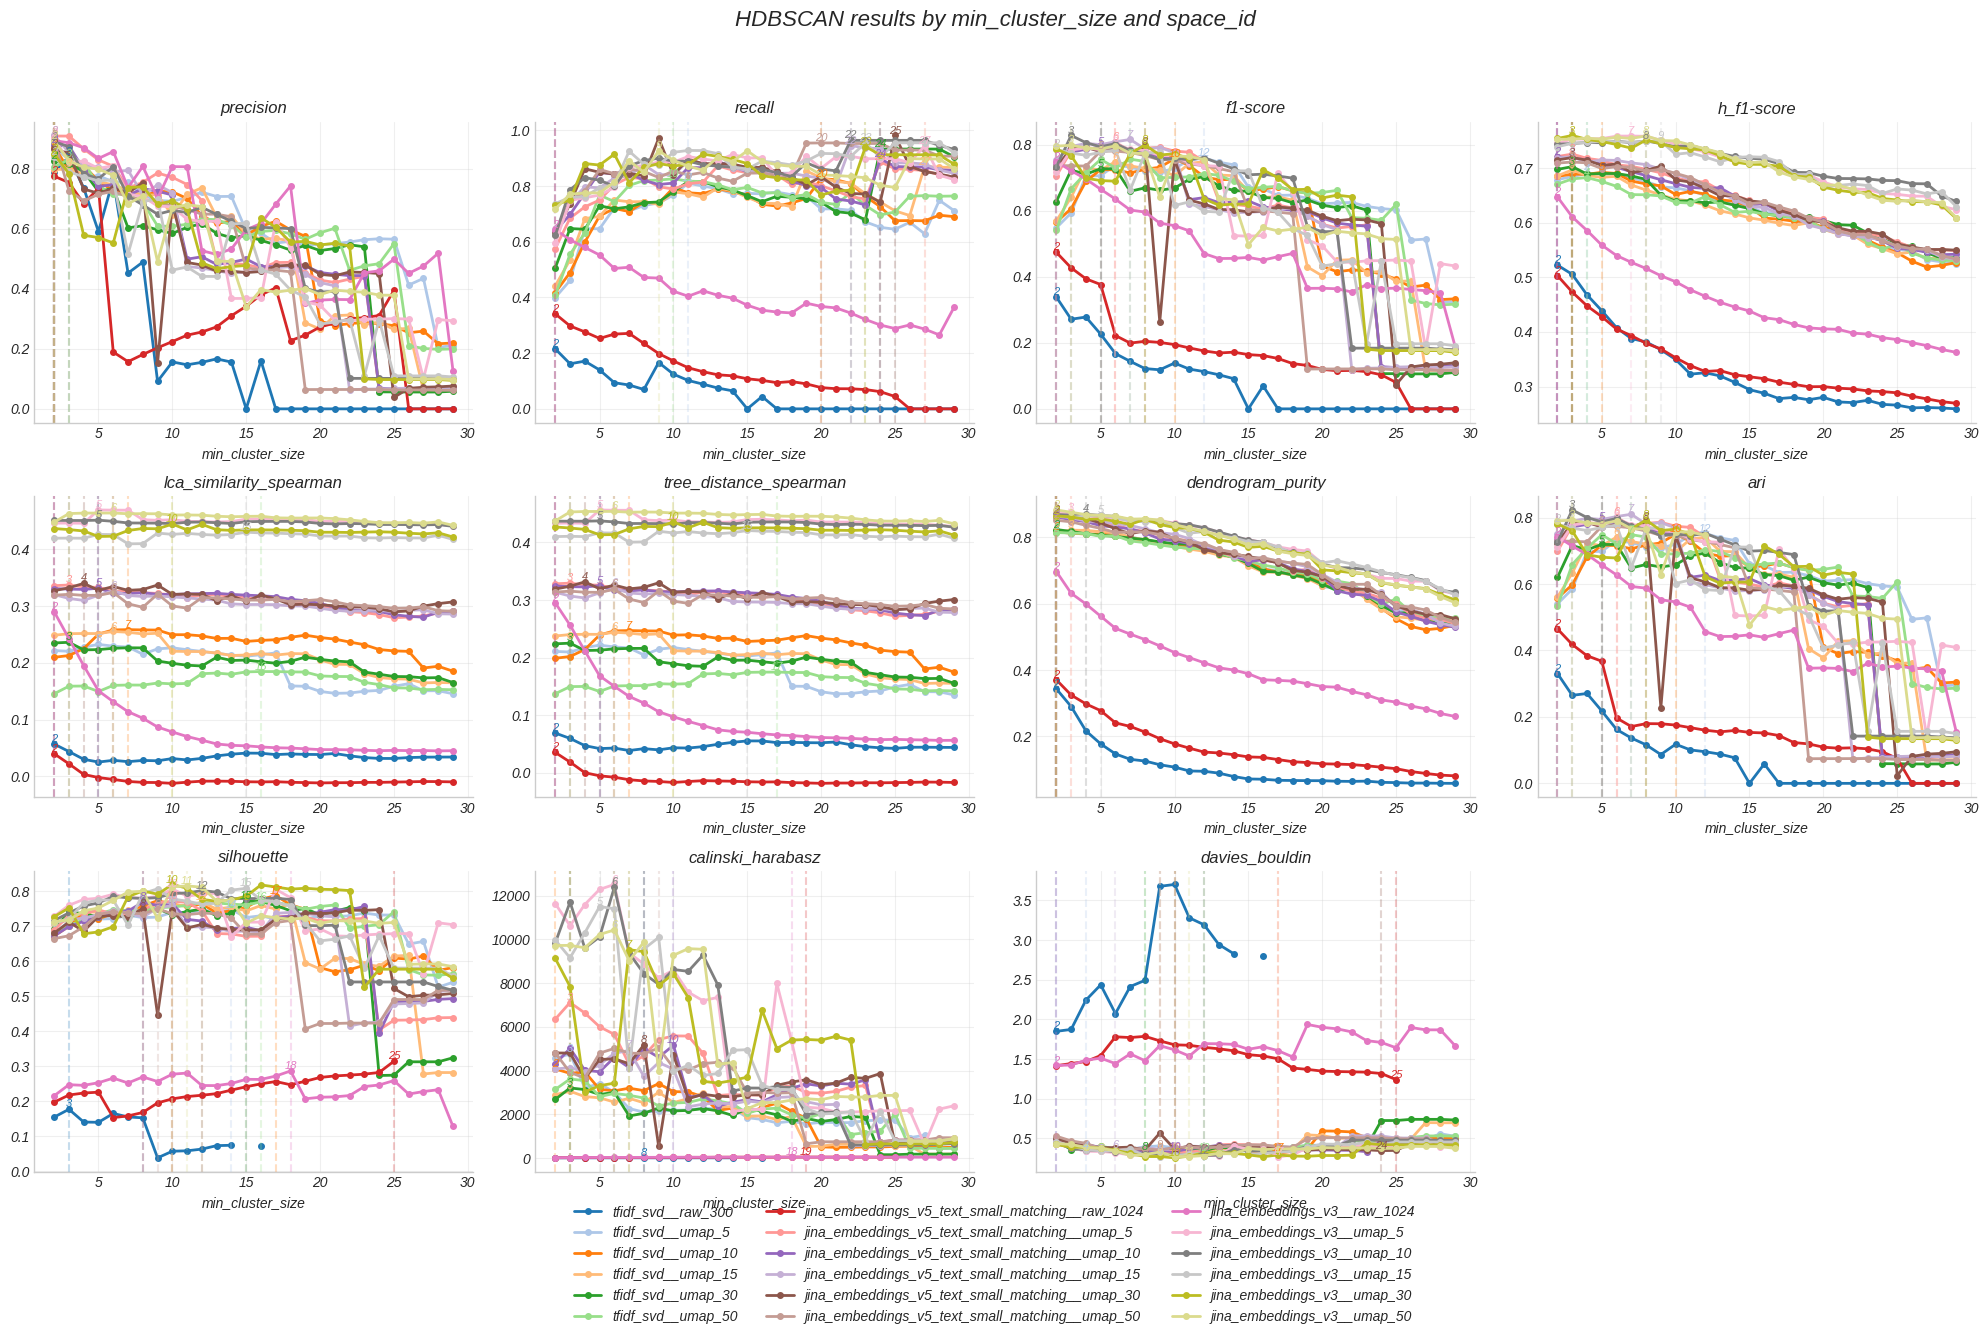

In [30]:
plot_hdbscan_results("results_hdbscan")

In [32]:
group_col = "space_id" if "space_id" in hdbscan_df.columns else "embeddings"

for group_name, part in hdbscan_df.groupby(group_col):
    corr = spearman_corr_with_pvalues(
        part,
        internal_metrics_for_corr,
        external_metrics,
    )
    print(group_name)
    display(corr.round(6))


jina_embeddings_v3__raw_1024


,precision,recall,f1-score,ari,h_precision,h_recall,h_f1-score,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity
silhouette,0.642036,0.178982,0.539135,0.559934,0.378216,0.412698,0.412698,0.398467,0.411604,0.412698
calinski_harabasz,-0.661741,-0.868637,-0.699507,-0.699507,-0.819923,-0.804050,-0.804050,-0.807882,-0.801314,-0.804050
davies_bouldin_inv,0.900383,0.665572,0.849480,0.857690,0.776683,0.762452,0.762452,0.771757,0.771210,0.762452


jina_embeddings_v3__umap_10


,precision,recall,f1-score,ari,h_precision,h_recall,h_f1-score,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity
silhouette,0.717049,-0.426914,0.768444,0.768444,0.382790,0.693257,0.753205,0.541186,0.575835,0.693807
calinski_harabasz,0.953578,-0.764023,0.933683,0.933683,-0.196345,0.938001,0.911601,0.790880,0.810679,0.933601
davies_bouldin_inv,0.666206,-0.408124,0.741365,0.741365,0.348141,0.649808,0.724606,0.501587,0.530186,0.653658


jina_embeddings_v3__umap_15


...

,precision,recall,f1-score,ari,h_precision,h_recall,h_f1-score,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity
silhouette,0.305205,-0.398134,0.353973,0.353973,0.220153,0.232749,0.233297,0.247536,0.243702,0.237678
calinski_harabasz,0.944110,-0.584845,0.896986,0.896986,0.751369,0.902519,0.903615,0.674699,0.662103,0.905805
davies_bouldin_inv,0.682192,-0.384405,0.751781,0.751781,0.649507,0.674151,0.686199,0.553669,0.531763,0.675247


tfidf_svd__umap_5


,precision,recall,f1-score,ari,h_precision,h_recall,h_f1-score,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity
silhouette,0.274767,0.418777,0.636563,0.626710,0.149973,0.128079,0.142310,0.119869,0.165298,0.133005
calinski_harabasz,0.981938,-0.069249,0.586207,0.586754,0.805692,0.904215,0.885057,0.796388,0.792009,0.898741
davies_bouldin_inv,0.740558,0.330368,0.834154,0.831965,0.736180,0.689108,0.744390,0.711549,0.726875,0.694581


tfidf_svd__umap_50


,precision,recall,f1-score,ari,h_precision,h_recall,h_f1-score,lca_similarity_spearman,tree_distance_spearman,dendrogram_purity
silhouette,0.324576,0.475643,0.555556,0.555556,0.315818,0.275315,0.284072,0.823755,0.825397,0.271483
calinski_harabasz,0.991242,0.089765,0.800219,0.800219,0.917898,0.961686,0.961138,-0.056377,-0.054187,0.962781
davies_bouldin_inv,0.536398,0.621784,0.771210,0.771210,0.545703,0.524357,0.538041,0.570881,0.572523,0.527641


In [33]:
group_col = "space_id" if "space_id" in hdbscan_df.columns else "embeddings"

for group_name, part in hdbscan_df.groupby(group_col):
    best_by_f1 = part.loc[part["f1-score"].idxmax()]
    best_by_hf1 = part.loc[part["h_f1-score"].idxmax()]
    best_by_ch = part.loc[part["calinski_harabasz"].idxmax()]
    best_by_sil = part.loc[part["silhouette"].idxmax()]
    best_by_db = part.loc[part["davies_bouldin"].idxmin()]

    print("\n", group_name)
    print("Best by F1:", best_by_f1["min_cluster_size"], " | ", best_by_f1["f1-score"])
    print("Best by hF1:", best_by_hf1["min_cluster_size"], " | ", best_by_hf1["h_f1-score"])
    print("=" * 50)
    print("Selected by CH:", best_by_ch["min_cluster_size"], " | ", best_by_ch["f1-score"], best_by_ch["h_f1-score"])
    print("Selected by silhouette:", best_by_sil["min_cluster_size"], " | ", best_by_sil["f1-score"], best_by_sil["h_f1-score"])
    print("Selected by DB:", best_by_db["min_cluster_size"], " | ", best_by_db["f1-score"], best_by_db["h_f1-score"])



 jina_embeddings_v3__raw_1024
Best by F1: 2  |  0.7485236508214933
Best by hF1: 2  |  0.6471015628757854
Selected by CH: 18  |  0.47051546391752574 0.41380359224268937
Selected by silhouette: 18  |  0.47051546391752574 0.41380359224268937
Selected by DB: 2  |  0.7485236508214933 0.6471015628757854

 jina_embeddings_v3__umap_10
Best by F1: 3  |  0.8275022495104006
Best by hF1: 8  |  0.7496910108506756
Selected by CH: 6  |  0.8027499747244969 0.749197335053799
Selected by silhouette: 12  |  0.7603789234731742 0.7343152390545395
Selected by DB: 12  |  0.7603789234731742 0.7343152390545395

 jina_embeddings_v3__umap_15
Best by F1: 2  |  0.7852931718297781
Best by hF1: 9  |  0.749197192447676
Selected by CH: 5  |  0.7764995083579155 0.7489743816949194
Selected by silhouette: 15  |  0.7200673117374843 0.7206858670111266
Selected by DB: 9  |  0.7775246772968869 0.749197192447676

 jina_embeddings_v3__umap_30
Best by F1: 8  |  0.7987028028723651
Best by hF1: 3  |  0.7596424454211934
Selected 